# Customer Segmentation and Analytics  
## First Notebook: Data Preparation and EDA

This project aims to better understand customer behavior and heterogeneity through unsupervised learning techniques. It is based on an enhanced version of the Mall Customers dataset, extended with synthetic but logically consistent features to better reflect real-world retail and marketing contexts.

The dataset combines basic demographic attributes (e.g., age, gender, annual income) with enriched behavioral and financial indicators such as estimated savings, credit score, customer loyalty duration, and preferred product category. These additional variables are designed to capture multiple dimensions of customer value, spending behavior, and long-term engagement.

Unlike supervised learning problems, this project does not rely on a predefined target variable. The objective is instead to uncover latent customer segments by identifying natural groupings within the data. Particular attention is given to data cleaning, feature scaling, and encoding strategies to ensure meaningful and interpretable clustering outcomes.

The overall goal is to build actionable customer segments that can support use cases such as targeted marketing, personalization strategies, and customer portfolio management. This first notebook focuses on preparing the dataset and conducting exploratory data analysis to understand variable distributions and relationships. These steps establish a solid foundation for subsequent clustering and segment interpretation.

**Author:** J-F Jutras  
**Date:** January 2026  
**Dataset:** Enhanced Mall Customers Dataset (synthetic extension of the Kaggle Mall Customers dataset)

## 1.1-Data Loading and Overview

In [1]:
import kagglehub
import pandas as pd
import os
import pickle

#Download latest version
path = kagglehub.dataset_download("vikasjigupta786/customer-analytics-practice-dataset")

#Define dataset path
dataset_dir = "/kaggle/input/customer-analytics-practice-dataset"
csv_path = os.path.join(dataset_dir, "Mall_Customers_Enhanced.csv")

#Load full dataset
df = pd.read_csv(csv_path)

#Basic checks
display(df.head())
display(df.tail())

#Clone the public GitHub repository "jfj-utils" into the current Kaggle working directory.
#This downloads all files and folders from the repo so they can be used in the notebook.
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

#Add the cloned repository to the Python path so Python can import modules from it
import sys
sys.path.append("/kaggle/working/jfj-utils")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category
0,1,Male,19,15,39,18-25,11.10,456,3,Budget
1,2,Male,21,15,81,18-25,6.90,300,6,Luxury
2,3,Female,20,16,6,18-25,15.36,594,2,Budget
3,4,Female,23,16,77,18-25,7.79,300,6,Luxury
4,5,Female,31,17,40,26-35,12.47,480,5,Budget


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category
195,196,Female,35,120,79,26-35,56.80,850,7,Luxury
196,197,Female,45,126,28,36-50,102.48,850,5,Electronics
197,198,Male,32,126,74,26-35,63.84,850,6,Luxury
198,199,Male,32,137,18,26-35,120.56,850,4,Fashion
199,200,Male,30,137,83,26-35,61.19,850,7,Luxury


Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (188/188), done.
remote: Total 3527 (delta 231), reused 99 (delta 99), pack-reused 3240 (from 4)
Receiving objects: 100% (3527/3527), 1.18 MiB | 6.30 MiB/s, done.
Resolving deltas: 100% (2322/2322), done.


In [2]:
from ingestion.readers import check_data
check_data(df)


Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Age Group', 'Estimated Savings (k$)', 'Credit Score', 'Loyalty Years', 'Preferred Category'] 

Shape: (200, 10) 

Data types:
 CustomerID                  int64
Gender                     object
Age                         int64
Annual Income (k$)          int64
Spending Score (1-100)      int64
Age Group                  object
Estimated Savings (k$)    float64
Credit Score                int64
Loyalty Years               int64
Preferred Category         object
dtype: object 

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Age Group                 4
Estimated Savings (k$)    0
Credit Score              0
Loyalty Years             0
Preferred Category        0
dtype: int64 

Duplicates: 0 


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total

In [3]:
#Check duplicates excluding CustomerID (PK)
dup_mask = df.drop(columns=["CustomerID"]).duplicated()

#Number of duplicates
print("Number of duplicate rows (excluding CustomerID):", dup_mask.sum())

Number of duplicate rows (excluding CustomerID): 0


In [4]:
from eda.describe_structure import describe_structure
describe_structure(df, id_cols = ["CustomerID"])


=== Numeric Columns ===

                        count       mean         std     min     25%     50%  \
Age                     200.0   38.85000   13.969007   18.00   28.75   36.00   
Annual Income (k$)      200.0   60.56000   26.264721   15.00   41.50   61.50   
Spending Score (1-100)  200.0   50.20000   25.823522    1.00   34.75   50.00   
Estimated Savings (k$)  200.0   40.24795   21.333448    6.46   28.80   36.41   
Credit Score            200.0  743.68000  155.176727  300.00  697.00  833.00   
Loyalty Years           200.0    5.93000    1.570808    2.00    5.00    6.00   

                             75%     max  
Age                      49.0000   70.00  
Annual Income (k$)       78.0000  137.00  
Spending Score (1-100)   73.0000   99.00  
Estimated Savings (k$)   44.9675  120.56  
Credit Score            850.0000  850.00  
Loyalty Years             7.0000    9.00  

=== Boolean Columns ===

Empty DataFrame
Columns: []
Index: []

=== Categorical Columns ===

                  

This dataset contains 200 customers with 10 features covering demographics, income, spending behavior, savings, credit score, loyalty, and preferred product category. The data is clean (no duplicates, minimal missing values) and well-structured with a unique customer ID. Customers show diverse financial and spending profiles, with an average age of ~39, income of ~$61k, and high credit scores. The dataset is well-suited for EDA, customer segmentation, and predictive modeling.

In [5]:
#Display rows with missing values
df[df.isna().any(axis=1)]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category
33,34,Male,18,33,92,NaN,12.76,411,6,Luxury
65,66,Male,18,48,59,NaN,29.12,681,4,Electronics
91,92,Male,18,59,41,NaN,42.87,850,3,Electronics
114,115,Female,18,65,48,NaN,44.20,850,4,Electronics


In [6]:
#Handle missing values
df['Age Group'] = df['Age Group'].fillna(df['Age'].apply(lambda x: '18-25' if 18 <= x <= 25 else None))

#Quick check
df['Age Group'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 200 entries, 0 to 199
Series name: Age Group
Non-Null Count  Dtype 
--------------  ----- 
200 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


## 1.2-EDA

### Univariate Analysis

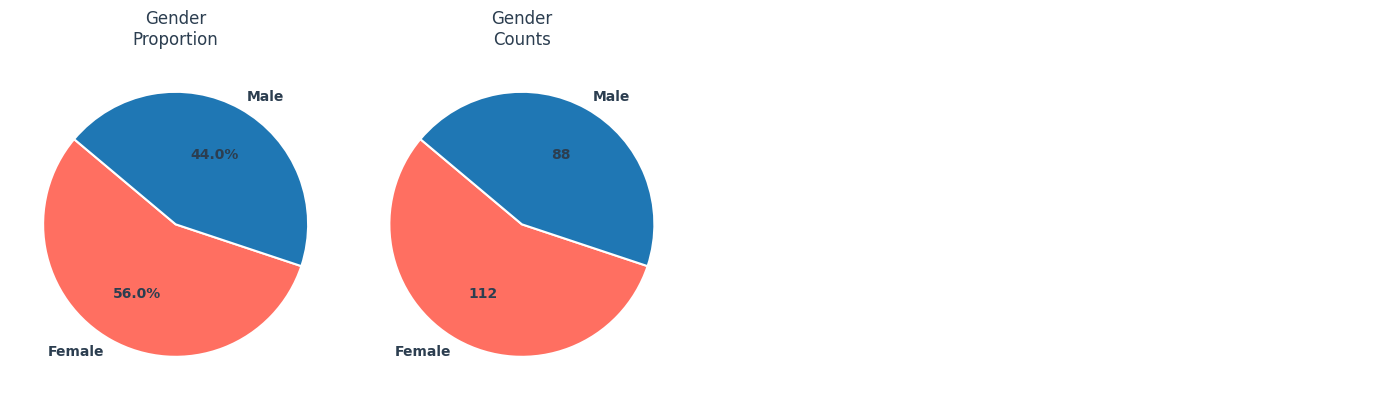

In [7]:
from visualization.explore_binary import plot_binary_distribution
plot_binary_distribution(df, ['Gender'])

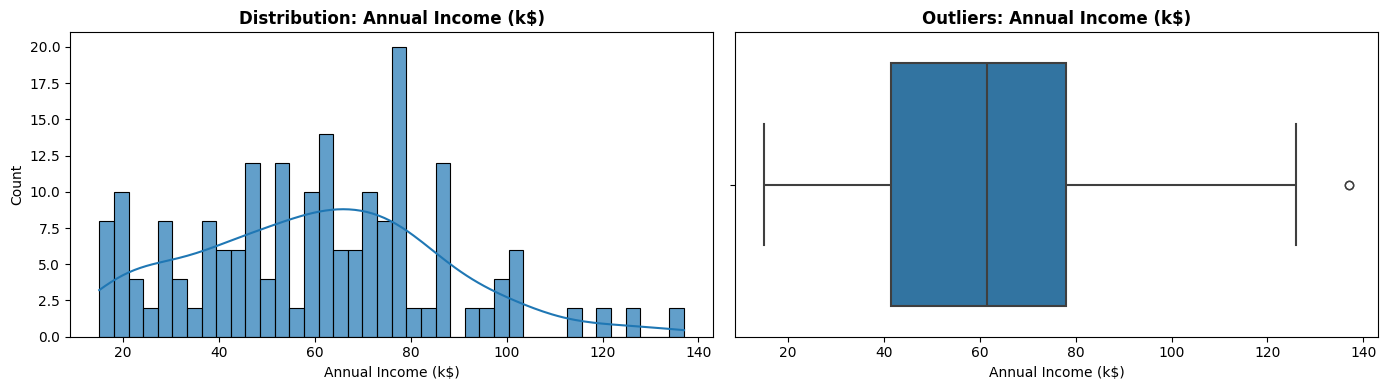

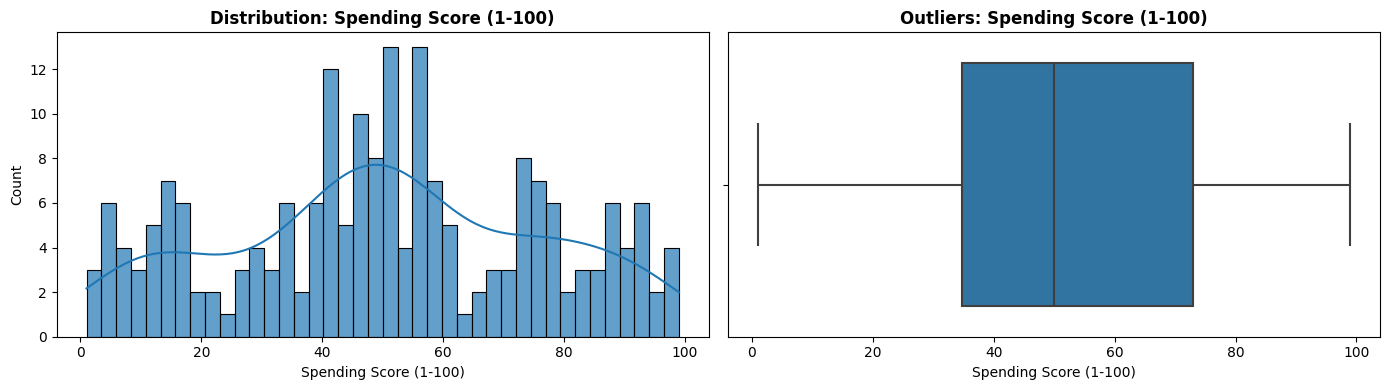

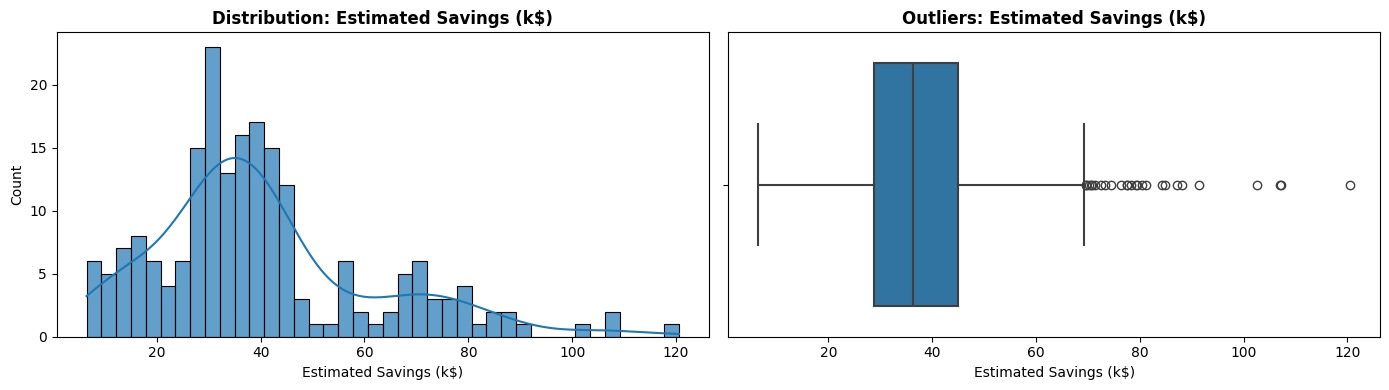

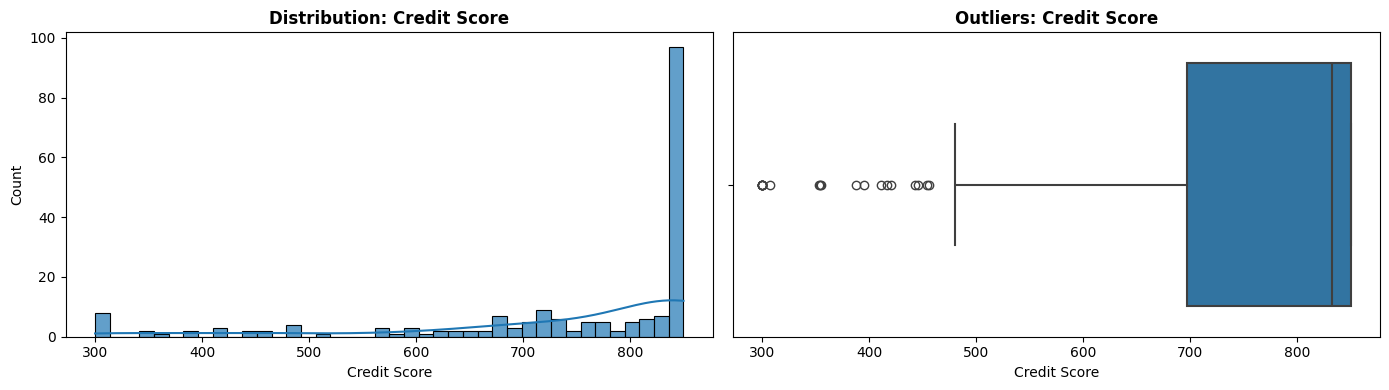

In [8]:
from visualization.explore_continuous import plot_numeric_distribution
numeric_cols = ['Annual Income (k$)', 'Spending Score (1-100)', 
                'Estimated Savings (k$)', 'Credit Score']
plot_numeric_distribution(df, numeric_cols)

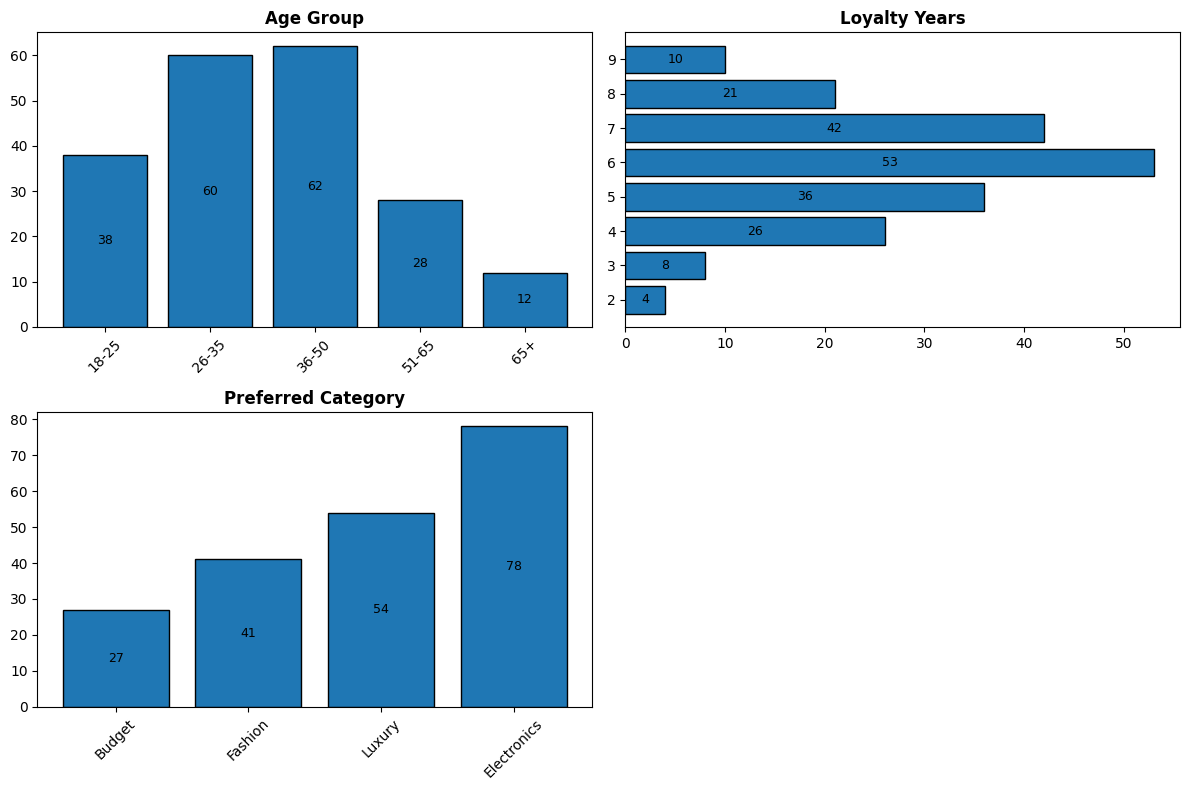

In [9]:
from visualization.explore_discrete import plot_discrete_distribution_grid
discrete_cols = ['Age Group', 'Loyalty Years', 'Preferred Category']

#Define the logical order of age groups
age_order = ['18-25', '26-35', '36-50', '51-65', '65+']

#Convert the column to a Categorical type with the specified order
df['Age Group'] = pd.Categorical(df['Age Group'], categories=age_order, ordered=True)

plot_discrete_distribution_grid(df, discrete_cols)

The preliminary exploration of the dataset reveals a high degree of heterogeneity across all customer dimensions. While demographic variables like Age Group and Gender are relatively well-distributed, behavioral and financial features show non-normal patterns that are critical for segmentation. Specifically, the Spending Score exhibits a distribution that signals the presence of naturally occurring clusters with vastly different consumption habits.

Furthermore, the significant skewness in Credit Score (left-skewed) and Estimated Savings (right-skewed) suggests a population polarized between a broad "financially stable" base and a select group of high-net-worth outliers. These findings confirm that the data is rich in latent structures, making it an ideal candidate for unsupervised learning and multi-dimensional clustering.

### Bivariate Analysis

**Annual Income vs. Spending Score**

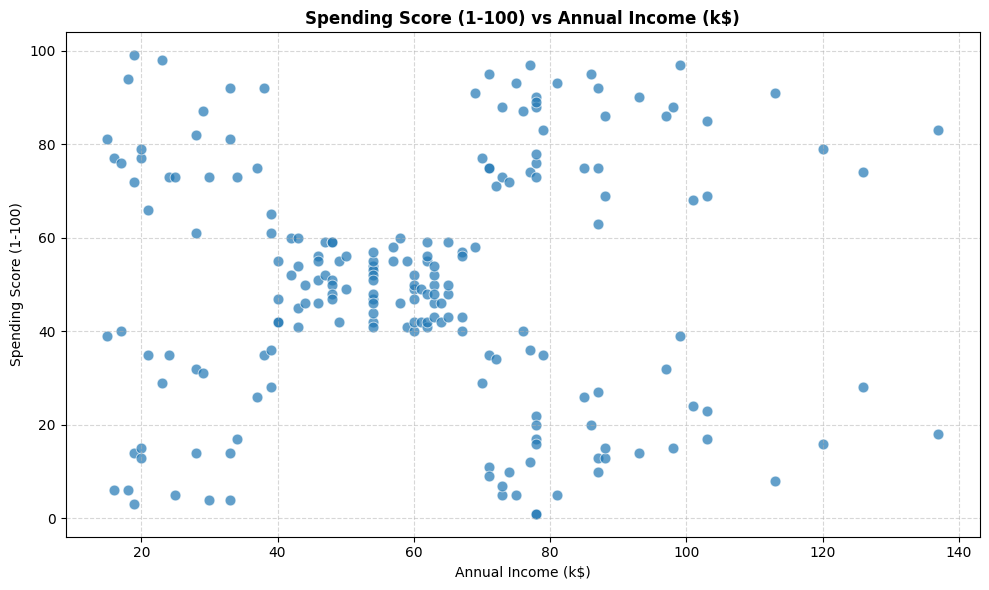

In [10]:
from visualization.explore_continuous import plot_scatter_grid
plot_scatter_grid(df, ['Annual Income (k$)'], ['Spending Score (1-100)'])

**Annual Income vs. Estimated Savings**

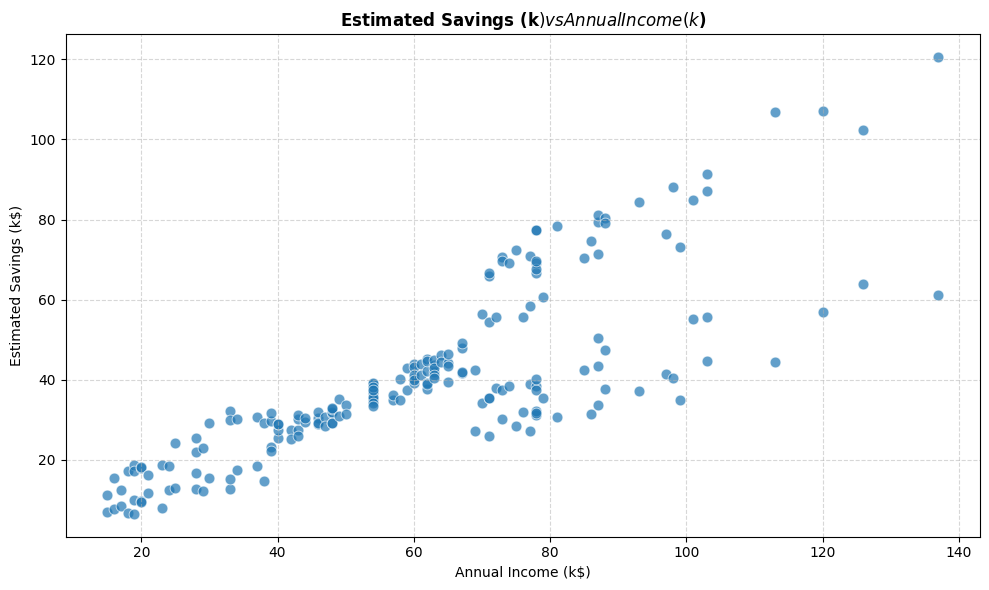

In [11]:
plot_scatter_grid(df, ['Annual Income (k$)'], ['Estimated Savings (k$)'])

**Gender vs. Spending Score**

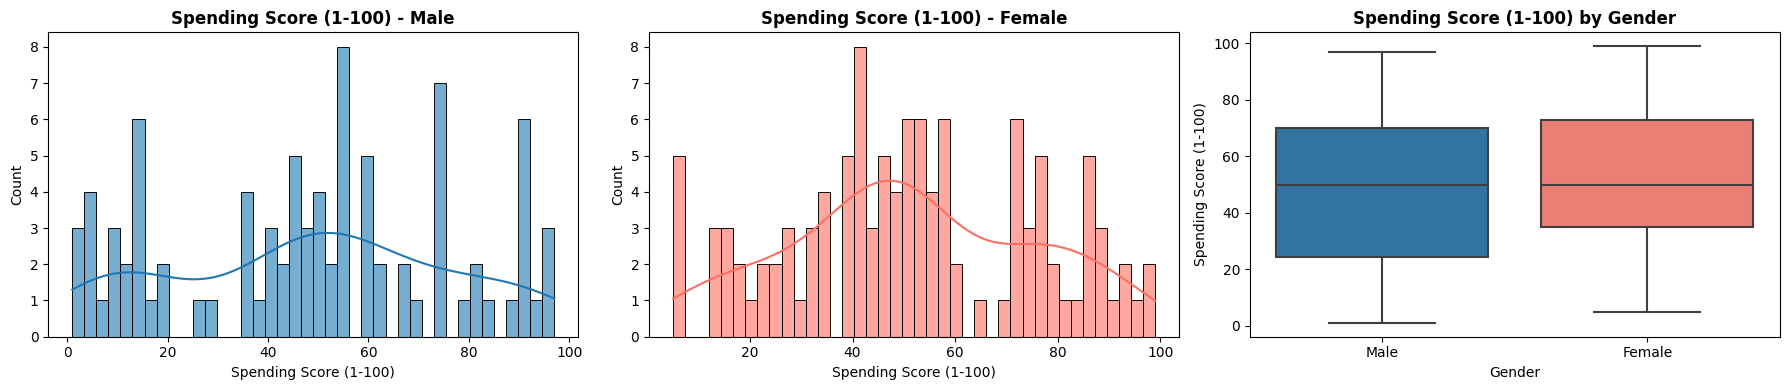

In [12]:
from visualization.explore_continuous import plot_numeric_bivariate
plot_numeric_bivariate(df, ['Spending Score (1-100)'], 'Gender' )

**Age Group vs. Spending Score**

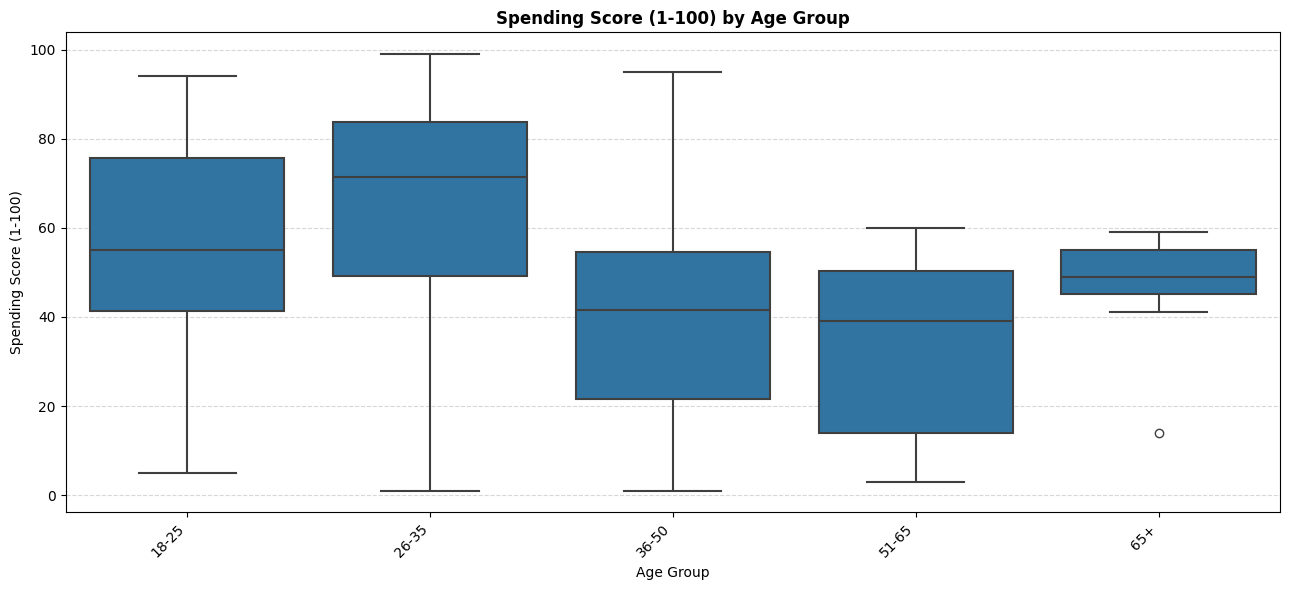

In [13]:
from visualization.explore_continuous import plot_box_grid
plot_box_grid(df, 'Spending Score (1-100)', 'Age Group', figsize = (13, 6))

**Preferred Category vs. Annual Income**

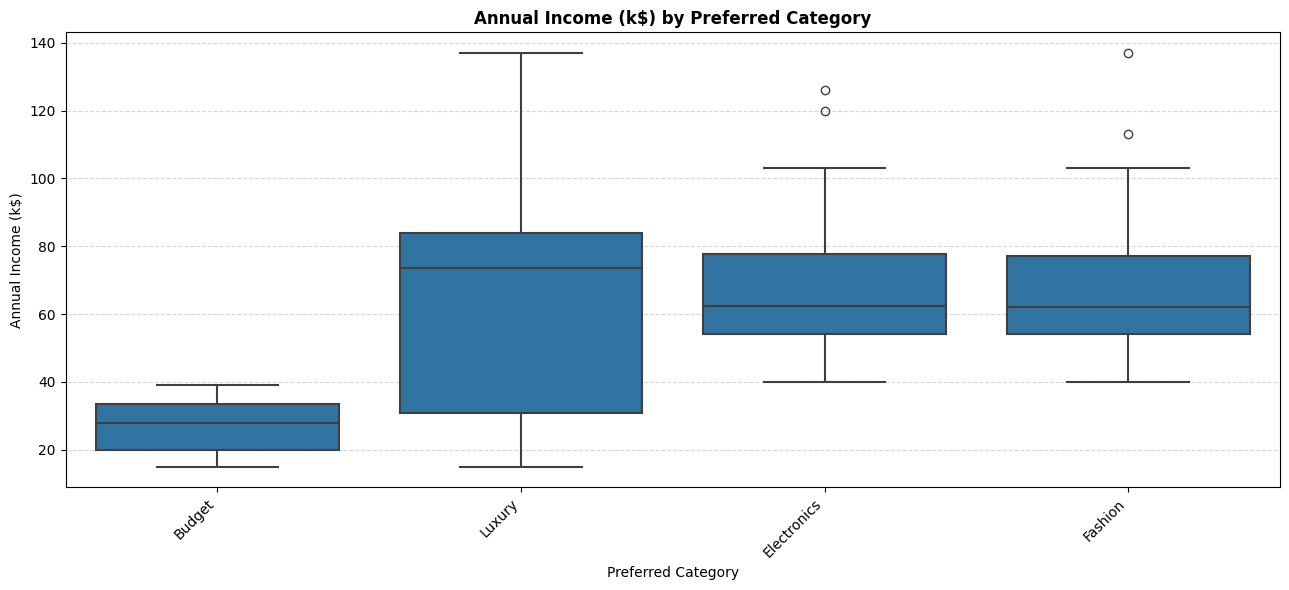

In [14]:
plot_box_grid(df, 'Annual Income (k$)', 'Preferred Category', figsize = (13, 6))

**Correlation Analysis**

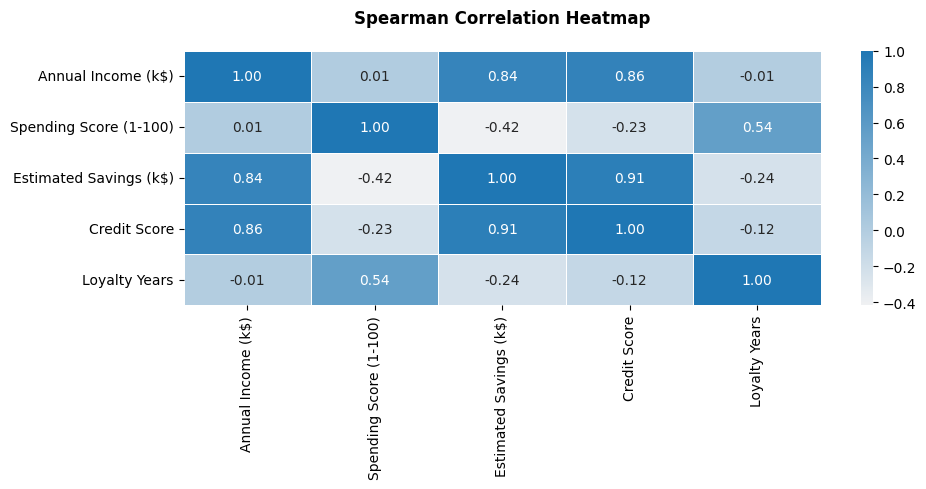

In [15]:
from visualization.explore_continuous import plot_correlation_heatmap
plot_correlation_heatmap(df, numeric_cols + ['Loyalty Years'], method = 'spearman', figsize = (10,5))

The bivariate exploration reveals that Spending Score is primarily driven by behavioral and demographic factors rather than absolute wealth, as evidenced by a near-zero correlation with Annual Income (0.008). Instead, Loyalty Years emerges as the strongest positive predictor of spending velocity (0.536), while a clear generational peak is identified in the 26-35 age group (median spending: 71.5).

Financial metrics show a strong linear coupling between Annual Income and Estimated Savings, highlighting a consistent wealth accumulation pattern. However, this financial stability is inversely related to immediate spending, confirming a "Saver vs. Spender" dichotomy. Furthermore, boxplot analysis shows that the Luxury category significantly deviates from others by having a much lower median savings despite its high income, suggesting that category preference is a key disruptor of standard financial correlations.

### Multivariate Analysis

**Gender X Numeric Features (Annual Income, Estimated Savings, Spending Score, Credit Score)**

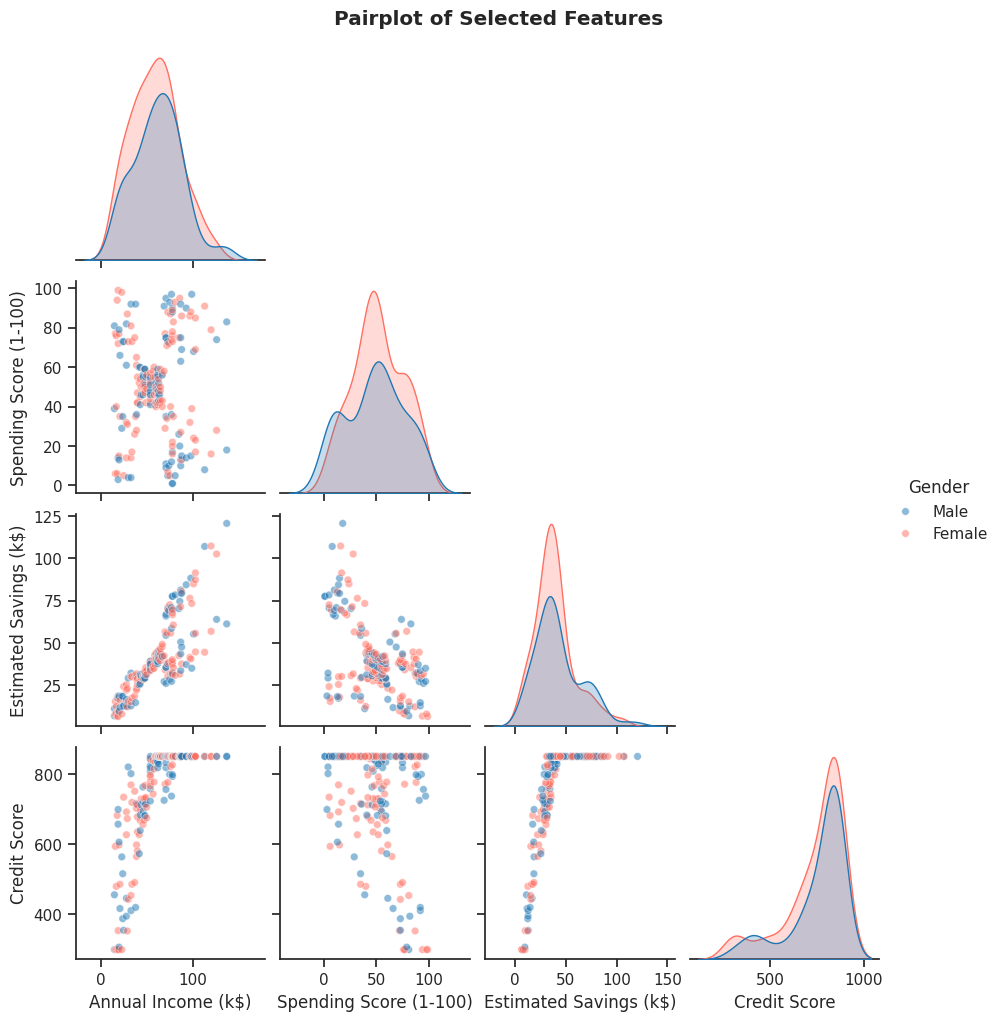

In [16]:
from visualization.explore_continuous import plot_pairplot
plot_pairplot(df, numeric_cols, 'Gender')

**Spending Score X Age Group X Gender**

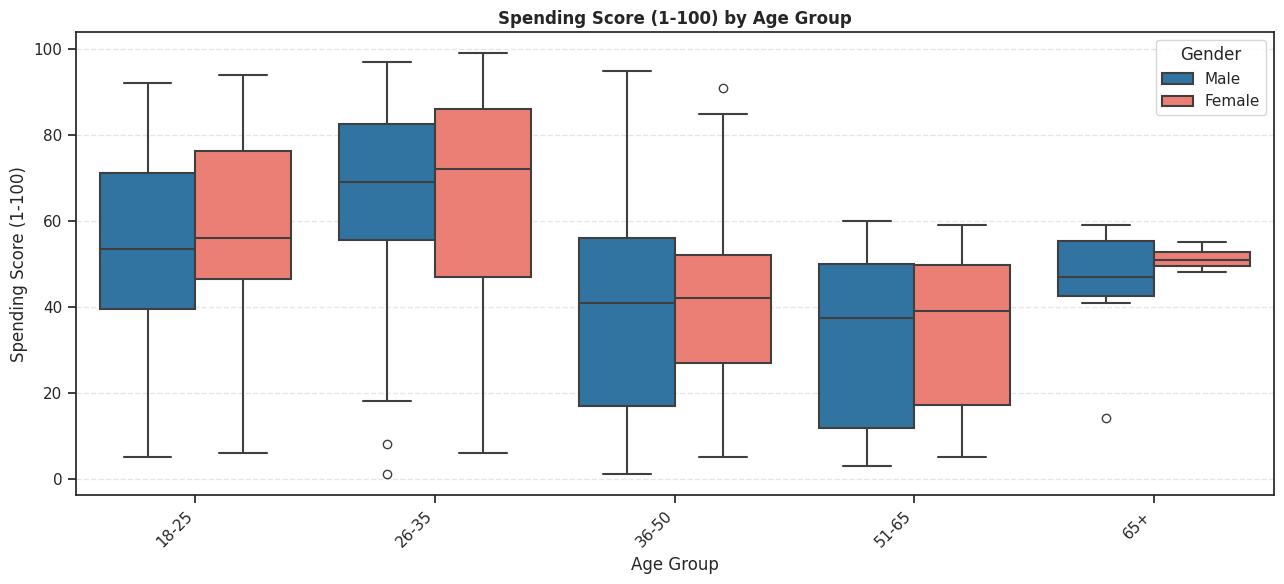

In [17]:
plot_box_grid(df, ['Spending Score (1-100)'], 'Age Group', hue_col = 'Gender', figsize = (13, 6))

**Estimated Savings X Age Group X Gender**

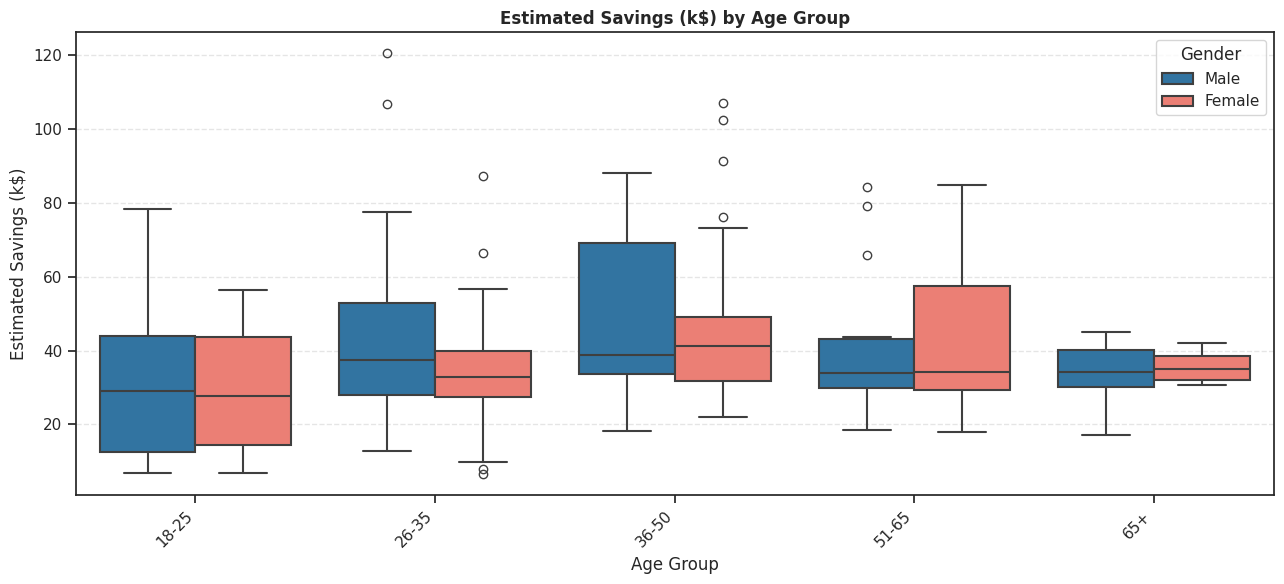

In [18]:
plot_box_grid(df, ['Estimated Savings (k$)'], 'Age Group', hue_col = 'Gender', figsize = (13, 6))

**Spending Score X Loyalty Years X Age Group**

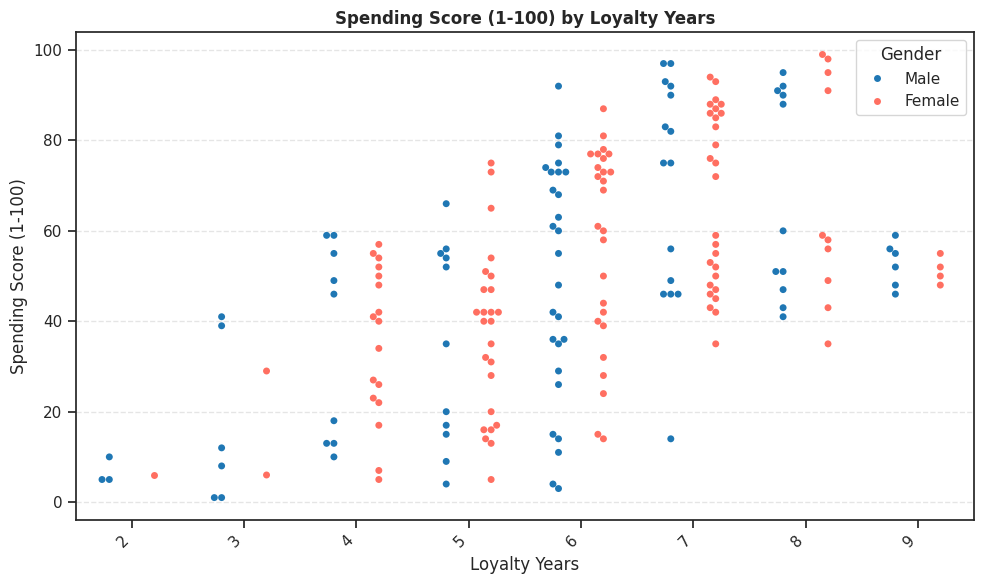

In [19]:
from visualization.explore_continuous import plot_swarm_grid
plot_swarm_grid(df, ['Spending Score (1-100)'], 'Loyalty Years', hue_col = 'Gender')

**Preferred Category X Age Group X Gender**

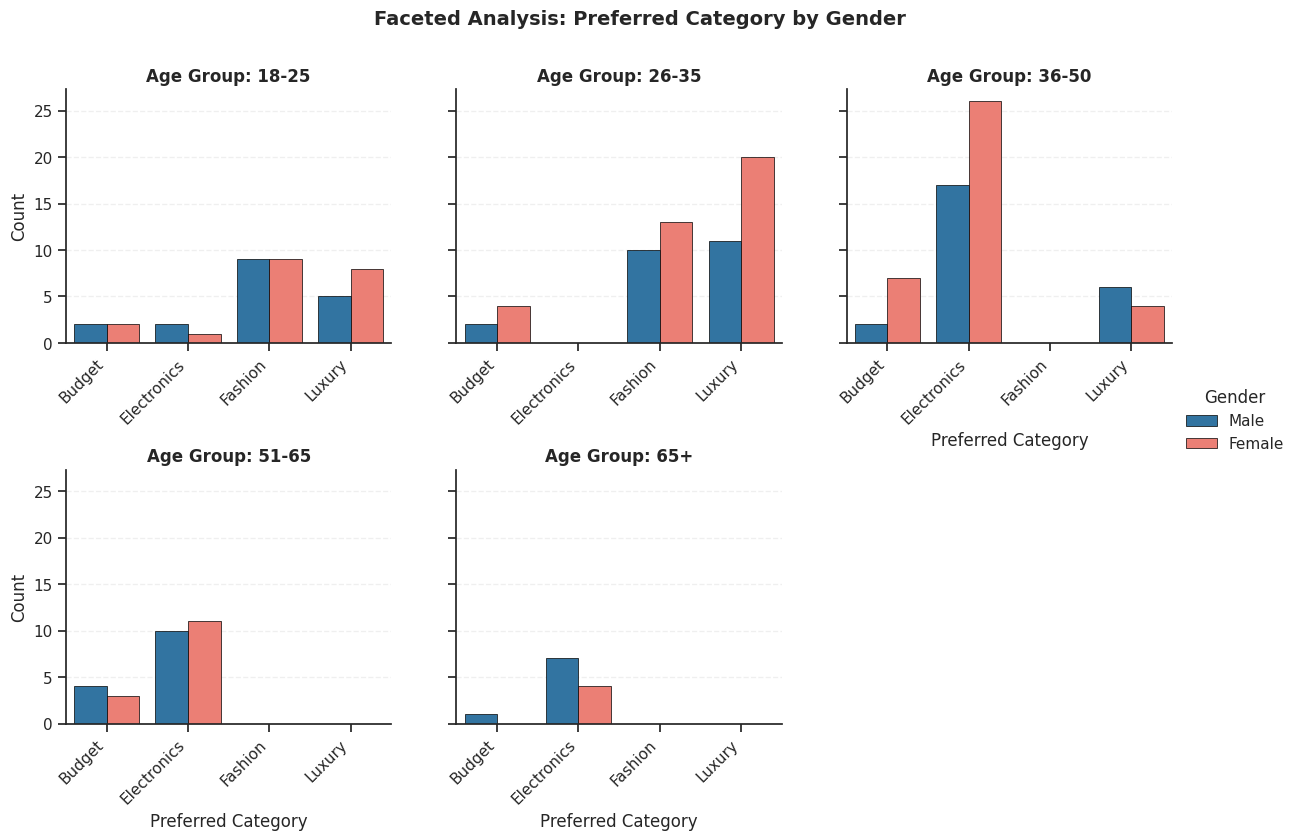

In [20]:
from visualization.explore_discrete_multivariate import plot_faceted_countplot
plot_faceted_countplot(df, x_col='Preferred Category', hue_col='Gender', facet_col='Age Group')

**Spending Score X Preferred Category X Age Group**

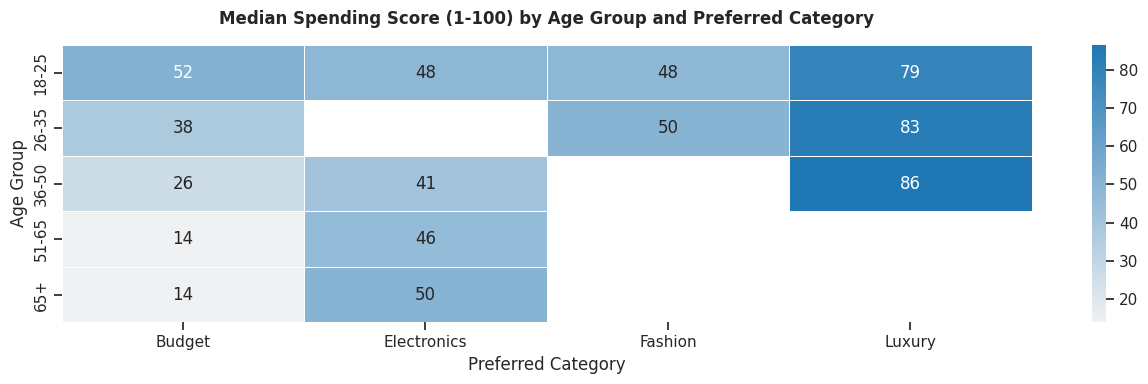

In [21]:
from visualization.explore_continuous import plot_heatmap_grid
plot_heatmap_grid(df, 'Spending Score (1-100)', 'Age Group', 'Preferred Category', figsize = (13,4))

The multivariate analysis reveals clear patterns in customer behavior and financial profiles. Gender differences are relatively modest: males tend to have slightly higher annual income and savings, but spending scores are comparable across genders. Age, however, is a stronger driver of behavior, with the 26–35 age group showing the highest spending, especially in Luxury and Fashion categories. Older age groups spend less overall, while younger adults demonstrate both moderate spending and targeted preferences.

Loyalty strongly correlates with spending: customers with more years of engagement consistently show higher spending scores, highlighting a “loyalty-to-spend” effect that is independent of gender. Preferences for product categories are age-dependent, with Budget favored by middle-aged adults, Electronics by 36–50-year-olds, Fashion by younger adults, and Luxury peaking among 26–50-year-olds.

Finally, heatmap analysis confirms these patterns and illustrates the “Spender vs. Saver” dichotomy: high-spending segments concentrate in Luxury and Fashion among adults, while savings accumulate more in older or male customers. These insights provide a solid foundation for defining actionable customer segments and tailoring marketing strategies.

## 1.3-Summary - Notebook 1

| Step | Key Actions | Main Insights & Results |
|------|-------------|------------------------|
| 1. Setup & Ingestion | Dataset download, cloning of jfj-utils, and global BI style application. | Environment initialized; validated 200 customer profiles with 10 features. |
| 2. Structure & Cleaning | Duplicate checks and logical imputation of Age Group based on Age values. | 100% data integrity; handled missing categorical values without dropping rows. |
| 3. Univariate Analysis | Distribution analysis via Histograms, Boxplots, and Lollipop plots. | Identified multi-modal patterns in Spending Score and heavy left-skew in Credit Score. |
| 4. Bivariate Analysis | Scatter plots and Boxplot grids (e.g., Income vs. Spending). | Key Finding: Income does not drive spending (0.008 corr). Loyalty is the primary spending driver. |
| 5. Correlation Study | Spearman correlation matrix between financial and behavioral metrics. | Strong linear coupling between Income and Savings; clear "Saver vs. Spender" dichotomy. |
| 6. Multivariate Analysis | Pairplots, Faceted Countplots, and Pivot Heatmaps. | Segment Discovery: 26-35 age group dominates Luxury/Fashion. Loyalty-to-spend effect is gender-independent. |